In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import matplotlib.gridspec as gridspec

In [5]:
#Load data and models
r300 = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest2_6spots_R300.txt')

model1 = np.loadtxt('./data/retrievals/star_narrow_priors/niriss_r300_lowm_star_priors-_TD_median_result.txt')
model2 = np.loadtxt('./data/retrievals/other/niriss_r300_xh2o_wide_star-_TD_median_result.txt')
model3 = np.loadtxt('./data/retrievals/other/V1298Tauc_sh_model_T_spot_2450_spot_fraction_0p5-_fwd_model.txt')

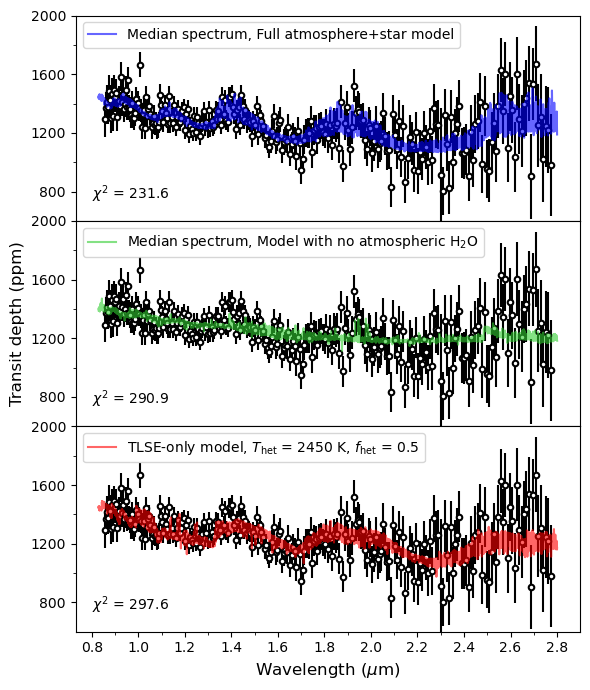

In [13]:
#Create figure and axes
fig = plt.figure(figsize=(6, 7))
gs = gridspec.GridSpec(nrows=3, ncols=1, hspace=0) 

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)

axs = [ax1,ax2,ax3]

#Plot data on every axis
for ax in axs:
    ax.errorbar(r300[:,0],r300[:,2]*1e6,yerr=r300[:,3]*1e6,ls='None',marker='o',markersize=4,color='black',mfc='white',mew=1.5, rasterized=True)

#Process models
model1_lam = model1[:,0]
model1_td = gaussian_filter1d(model1[:,1],sigma=5)

model2_lam = model2[:,0]
model2_td = gaussian_filter1d(model2[:,1],sigma=5)

model3_lam = model3[:,0]
model3_td = gaussian_filter1d(model3[:,1],sigma=5)

offset = np.mean(model3_td)-np.mean(r300[:,2])

#Plot models
ax1.plot(model1_lam,model1_td*1e6,zorder=1000.02,label='Median spectrum, Full atmosphere+star model',color='blue',alpha=0.6, rasterized=True)
ax2.plot(model2_lam,model2_td*1e6,zorder=1000.02,label='Median spectrum, Model with no atmospheric H$_2$O',color='limegreen',alpha=0.6, rasterized=True)
ax3.plot(model3_lam,(model3_td-offset)*1e6,zorder=1000.02,label=r'TLSE-only model, $T_{\rm het}$ = 2450 K, $f_{\rm het}$ = 0.5',color='red',alpha=0.6, rasterized=True)

#Add chi squared values
ax1.text(0.8,750,r'$\chi^2$ = 231.6')
ax2.text(0.8,750,r'$\chi^2$ = 290.9')
ax3.text(0.8,750,r'$\chi^2$ = 297.6')

#Axis labels, limits, legend
ax3.set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax2.set_ylabel('Transit depth (ppm)', fontsize=12)

ax1.set_ylim(600,2000)
ax2.set_ylim(600,2000)
ax3.set_ylim(600,2000)

ax1.legend(loc='upper left')
ax2.legend(loc='upper left')
ax3.legend(loc='upper left')

#Ticks
ax3.set_xticks(np.arange(0.8,2.81,0.2))
ax3.set_xticks(np.arange(0.8,2.81,0.1),minor=True)

for ax in axs:
    ax.set_yticks(np.arange(800,2100,400))
    ax.set_yticks(np.arange(800,2100,200),minor=True)

plt.tight_layout()
plt.savefig('./figures/Figure7_new.pdf', dpi=600, bbox_inches='tight')
plt.show()